# Lab 3.2 (OPT-1B) — Gradient Descent in 2D: Geometry, Conditioning, Line Search, and Basins [Student Version]

**Course:** Mathematical Foundations of Machine and Deep Learning (beginner+)  
**Format:** 1.5h guided lab (Colab/Jupyter)  
**Allowed libs:** numpy, matplotlib

This lab focuses entirely on **optimization in 2D**. We will first introduce the objective functions and visualize their geometry. Then we will implement gradient descent, study ill-conditioning, and compare fixed step sizes with Armijo backtracking. Finally, we will examine how initialization changes the final solution on a non-convex landscape.


## Learning objectives
1. Interpret a 2D objective through contour plots, gradient fields, and trajectories.
2. Implement gradient descent in 2D and return the full trajectory.
3. Explain why ill-conditioned quadratics cause zig-zag motion.
4. Implement Armijo backtracking in 2D and compare it against a fixed learning rate.
5. Analyze basin sensitivity on a non-convex function using multiple initializations.
6. Compare GD, SGD, and SGD with momentum on a 2D finite-sum objective.

## Lab flow
- Geometry first: define the 2D functions and visualize them.
- Optimization second: implement GD and inspect trajectories.
- Stability third: compare fixed step sizes and line search.
- Non-convexity next: study different basins on Himmelblau's function.
- Stochastic optimization last: compare GD, SGD, and SGD with momentum on a noisy finite-sum objective.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)


In [2]:
def contour_with_trajectory(f, traj=None, xlim=(-5, 5), ylim=(-5, 5), levels=30, title=""):
    xs = np.linspace(xlim[0], xlim[1], 300)
    ys = np.linspace(ylim[0], ylim[1], 300)
    X, Y = np.meshgrid(xs, ys)
    Z = f(X, Y)

    plt.figure(figsize=(6, 5))
    plt.contour(X, Y, Z, levels=levels)
    if traj is not None:
        traj = np.array(traj, dtype=float)
        plt.plot(traj[:, 0], traj[:, 1], marker="o", linewidth=2)
        plt.scatter(traj[0, 0], traj[0, 1], s=90, marker="s", label="start")
        plt.scatter(traj[-1, 0], traj[-1, 1], s=110, marker="*", label="end")
        plt.legend()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.2)
    plt.show()


def surface_plot(f, xlim=(-5, 5), ylim=(-5, 5), title=""):
    xs = np.linspace(xlim[0], xlim[1], 160)
    ys = np.linspace(ylim[0], ylim[1], 160)
    X, Y = np.meshgrid(xs, ys)
    Z = f(X, Y)

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")
    plt.show()


def gradient_field(grad, xlim=(-5, 5), ylim=(-5, 5), density=15, title=""):
    xs = np.linspace(xlim[0], xlim[1], density)
    ys = np.linspace(ylim[0], ylim[1], density)
    X, Y = np.meshgrid(xs, ys)
    U = np.zeros_like(X, dtype=float)
    V = np.zeros_like(Y, dtype=float)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            g = grad(np.array([X[i, j], Y[i, j]], dtype=float))
            U[i, j] = -g[0]
            V[i, j] = -g[1]

    plt.figure(figsize=(6, 5))
    plt.quiver(X, Y, U, V)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.2)
    plt.show()


def plot_objective_history(traj, f_scalar, title="Objective along trajectory"):
    vals = [f_scalar(p[0], p[1]) for p in traj]
    plt.figure(figsize=(6, 3.5))
    plt.plot(vals, marker="o")
    plt.title(title)
    plt.xlabel("iteration")
    plt.ylabel("f(x_k, y_k)")
    plt.grid(True, alpha=0.3)
    plt.show()


## Intro: why start from geometry?

In 2D we can directly see what gradient descent is reacting to:
- **level sets** show the shape of the objective,
- **gradient vectors** show the steepest ascent direction,
- **trajectories** show how the algorithm moves through the landscape.

This makes 2D a useful bridge between formulas and optimization intuition.


## Module 1 — The 2D functions we will optimize

We will work with three functions throughout the lab:

1. **Quadratic:** a controllable convex function used to study conditioning.
2. **Double-well in y:** a mixed geometry example with quadratic behavior in x and non-convex behavior in y.
3. **Himmelblau:** a non-convex function with multiple minima, used to study basin sensitivity.

We define them first, and we visualize them before implementing any optimizer.


In [3]:
def make_quadratic(a=1.0, b=1.0):
    def f(x, y):
        return 0.5 * (a * x**2 + b * y**2)

    def grad(xy):
        x, y = xy
        return np.array([a * x, b * y], dtype=float)

    return f, grad


def double_well_quadratic(x, y):
    return np.power(x, 2) / 2 + 1 / 4 * np.power(y, 4) - 1 / 2 * np.power(y, 2)


def grad_double_well_quadratic(xy):
    x, y = xy
    return np.array([x, y**3 - y], dtype=float)


def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2


def grad_himmelblau(xy):
    x, y = xy
    dfdx = 4 * x * (x**2 + y - 11) + 2 * (x + y**2 - 7)
    dfdy = 2 * (x**2 + y - 11) + 4 * y * (x + y**2 - 7)
    return np.array([dfdx, dfdy], dtype=float)


f_iso, g_iso = make_quadratic(a=1.0, b=1.0)
f_ic, g_ic = make_quadratic(a=50.0, b=1.0)

himmelblau_minima = [
    (3.0, 2.0),
    (-2.805118, 3.131312),
    (-3.779310, -3.283186),
    (3.584428, -1.848126),
]

for p in himmelblau_minima:
    print(p, himmelblau(p[0], p[1]))


(3.0, 2.0) 0.0
(-2.805118, 3.131312) 1.0989296656869089e-11
(-3.77931, -3.283186) 3.797861082863832e-12
(3.584428, -1.848126) 8.894376497582423e-12


### Task 1 — Visualize the functions before optimizing

Look at the geometry of the level sets.
- For the isotropic quadratic, contour lines are circular.
- For the ill-conditioned quadratic, contour lines are elongated.
- For double_well_quadratic(x, y), the landscape is convex in x but has a double-well structure in y.
- For Himmelblau, multiple valleys and minima are visible.

**Expected takeaway:** the trajectory of GD will depend strongly on the geometry of these contours.


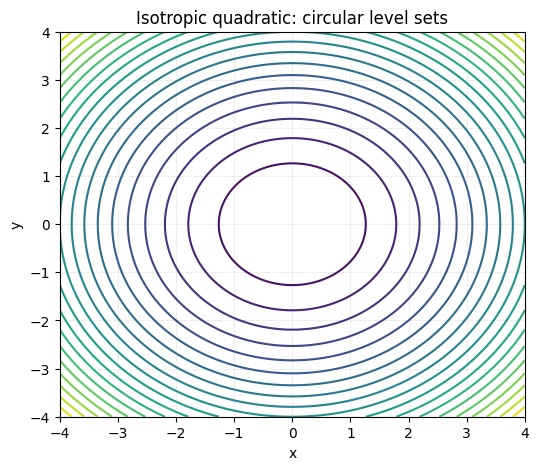

In [5]:
contour_with_trajectory(
    lambda X, Y: f_iso(X, Y),
    xlim=(-4, 4),
    ylim=(-4, 4),
    levels=25,
    title="Isotropic quadratic: circular level sets",
)

# TODO: Visualize the contour lines of f_ic over the domain x, y in [-4, 4]

# TODO: Visualize the contour lines of double_well_quadratic over the domain x, y in [-3, 3]

# TODO: Visualize the contour lines of himmelblau over the domain x, y in [-5,5]


In [7]:
# TODO: Visualize the surface_plot for  each function


### Task 2 — Visualize the gradient field

The arrows below show the direction of **steepest descent** after negating the gradient.

**What do you observe?**
- On the quadratic, the vectors reflect the anisotropy of the curvature.
- On double_well_quadratic(x, y), the vectors split the plane into regions flowing toward different y-basins.
- On Himmelblau, the vectors point into different basins depending on the region.


In [9]:
# TODO: Visualize the gradient_field for  each function


## Module 2 — Implement gradient descent in 2D

Now that the geometry is visible, we implement fixed-step gradient descent and store the full trajectory. That trajectory will be reused in every later experiment.


### Task 3 — Implement `gd_2d`

Use the update
\[
\mathbf{x}_{k+1} = \mathbf{x}_k - \eta 
abla f(\mathbf{x}_k).
\]

Return all iterates, not just the final point.

**Expected takeaway:** in 2D, the trajectory itself is part of the answer.


In [10]:
def gd_2d(start_xy, lr, iters, grad):
    """
    Fixed-step gradient descent in 2D.
    Returns a list [x_0, x_1, ..., x_iters].
    """
    x = np.array(start_xy, dtype=float)
    traj = [x.copy()]

    for k in range(iters):
        g = grad(x)
        # TODO: implement one GD step x <- x - lr * g, It can work exactyly te same as in 1D

    return traj


traj_test = gd_2d(start_xy=(2.0, 2.0), lr=0.1, iters=10, grad=g_iso)
print('last point:', traj_test[-1])


last point: [2. 2.]


### Task 4 — Compare isotropic and ill-conditioned quadratics

Use the same start point and the same learning rate.

**What do you observe?**
- On the isotropic quadratic, motion is direct and stable.
- On the ill-conditioned quadratic, motion starts to zig-zag across the valley.

**Expected takeaway:** conditioning is a geometric explanation for optimization difficulty.


In [ ]:
start_xy = (3.0, 3.0)
iters = 50
lr = 0.01

# TODO: run GD on the isotropic and ill-conditioned quadratics
traj_iso = None
traj_ic = None

# TODO: Visualize with contour_with_trajectory, plot_objective_history

### Task 5 — Step-size sweep on the ill-conditioned quadratic

Try several learning rates on the same problem.

**What do you observe?**
- Small `lr`: slow but safe.
- Medium `lr`: faster but still stable.
- Large `lr`: stronger oscillations and possible divergence.

**Expected takeaway:** the safe step-size range depends on curvature, not just on the algorithm.


In [ ]:
lrs_try = [0.01, 0.03, 0.05, 0.12]
for lr in lrs_try:
    # TODO: run GD on the ill-conditioned quadratic and visualize the trajectory
    pass


## Module 3 — Armijo backtracking in 2D

Fixed learning rates can be hard to tune. We now implement Armijo backtracking, which shrinks the step until it produces sufficient decrease.


### Task 6 — Implement Armijo backtracking in 2D

For a point `x` and gradient `g`, accept `eta` when
\[
f(x - \eta g) \le f(x) - c \eta \|g\|^2.
\]

If the condition fails, set `eta <- beta * eta` and try again.


In [ ]:
def armijo_backtracking_2d(f_scalar, x, g, eta0=1.0, c=1e-4, beta=0.5, max_steps=25):
    eta = float(eta0)
    fx = float(f_scalar(x[0], x[1]))

    for j in range(max_steps):
        x_new = x - eta * g

        # TODO: implement the Armijo condition in @D Version
        if False:
            return eta, j

        eta *= beta

    return eta, max_steps


def gd_2d_with_armijo(start_xy, iters, f_scalar, grad, eta0=1.0, c=1e-4, beta=0.5, max_steps=25):
    x = np.array(start_xy, dtype=float)
    traj = [x.copy()]
    eta_hist = []
    backtrack_hist = []

    for k in range(iters):
        g = grad(x)
        eta, bt = armijo_backtracking_2d(f_scalar, x, g, eta0=eta0, c=c, beta=beta, max_steps=max_steps)
        eta_hist.append(eta)
        backtrack_hist.append(bt)
        x = x - eta * g
        traj.append(x.copy())

    return traj, eta_hist, backtrack_hist


### Task 7 — Compare fixed step size vs Armijo on the ill-conditioned quadratic

Use a deliberately aggressive trial step. The fixed-step method should struggle more than Armijo.

**Expected takeaway:** line search adapts to local geometry and can reduce manual tuning.


In [ ]:
# TODO: compare a large fixed step against Armijo backtracking on the ill-conditioned quadratic
traj_fixed = None
traj_armijo, eta_hist, backtrack_hist = None, None, None



### Task 7a — Compare fixed step size vs Armijo on the other functions

In [13]:
#TODO Place for your playground

## Module 4 — Non-convex basins on Himmelblau

We now switch to a landscape with multiple minima. The optimizer is the same, but the outcome now depends heavily on initialization.


### Task 8 — Sanity-check the gradient numerically

Before trusting long optimization runs on a non-convex function, it is good practice to verify the gradient with finite differences.


In [11]:
def finite_diff_grad_2d(f_scalar, xy, eps=1e-6):
    x, y = float(xy[0]), float(xy[1])
    dfdx = (f_scalar(x + eps, y) - f_scalar(x - eps, y)) / (2 * eps)
    dfdy = (f_scalar(x, y + eps) - f_scalar(x, y - eps)) / (2 * eps)
    return np.array([dfdx, dfdy], dtype=float)


xy0 = np.array([0.1, -0.2], dtype=float)
g_analytic = grad_himmelblau(xy0)
g_numeric = finite_diff_grad_2d(himmelblau, xy0)
rel_err = np.linalg.norm(g_analytic - g_numeric) / (np.linalg.norm(g_analytic) + np.linalg.norm(g_numeric) + 1e-12)

print('analytic:', g_analytic)
print('numeric :', g_numeric)
print('relative error:', rel_err)


analytic: [-18.196 -16.892]
numeric : [-18.196 -16.892]
relative error: 3.186696052932105e-10


### Task 9 — Run GD from several starting points on Himmelblau

Keep the optimizer fixed and only change the initialization.

**What do you observe?**
- Different starting points are attracted to different minima.
- The contour plot shows basin structure directly.

**Expected takeaway:** on non-convex objectives, initialization is part of the algorithmic behavior.


In [12]:
starts = [(-4.5, 4.5), (-3.5, -3.0), (3.5, 0.5), (4.0, 4.0)]
lr = 0.01
iters = 80

for s in starts:
    # TODO: run GD on Himmelblau with different starting points. Visualize the trajectory and  objective history.
    pass


In [ ]:
### Task 9a — Run GD and Armio from each function.

## Module 5 — SGD on a 2D finite-sum objective

To make **stochastic** gradient descent meaningful, we need an objective built from many components:
\[
F(x, y) = rac{1}{n} \sum_{i=1}^n f_i(x, y).
\]

Instead of optimizing one deterministic surface directly, we now optimize an **average** of slightly shifted double-well functions. Full-batch GD uses the exact average gradient, while SGD uses only one randomly sampled component gradient at each step.


### Task 10 — Build a finite-sum version of `double_well_quadratic`

We create many component functions by shifting the double-well slightly in `x` and `y`.

**What do you observe?**
- The averaged surface is still smooth, but the individual component gradients disagree locally.
- This disagreement is the source of SGD noise.


In [ ]:
# TODO: choose how many component functions to average and generate small random shifts
num_components = None
component_shifts = None



def component_value(x, y, shift):
    sx, sy = shift
    return double_well_quadratic(x - sx, y - sy)


def component_grad(xy, shift):
    sx, sy = shift
    x, y = xy
    return grad_double_well_quadratic(np.array([x - sx, y - sy], dtype=float))


def finite_sum_objective(x, y, shifts=component_shifts):
    vals = [component_value(x, y, shift) for shift in shifts]
    return np.mean(vals, axis=0)


def finite_sum_grad(xy, shifts=component_shifts):
    grads = [component_grad(xy, shift) for shift in shifts]
    return np.mean(grads, axis=0)


#TODO Plot contur of this function.


### Task 11 — Implement SGD in 2D

At each step, sample one component `f_i` and update using only its gradient.

**Expected takeaway:** SGD follows the right trend on average, but the trajectory is noisy because each step sees only partial information.


In [ ]:
def sgd_2d(start_xy, lr, iters, component_grad_fn, num_components, seed=0):
    x = np.array(start_xy, dtype=float)
    traj = [x.copy()]
    picked = []
    local_rng = np.random.default_rng(seed)

    for k in range(iters):
        # TODO: sample one component index, compute its gradient, and update x
        idx = 0  # replace this line
        traj.append(x.copy())
        picked.append(idx)

    return traj, picked


component_grad_fn = lambda xy, idx: component_grad(xy, component_shifts[idx])
traj_sgd_test, picked_test = sgd_2d(
    start_xy=(1.4, 0.3),
    lr=0.05,
    iters=5,
    component_grad_fn=component_grad_fn,
    num_components=num_components,
    seed=0,
)
print('picked indices:', picked_test)
print('last point:', traj_sgd_test[-1])


In [14]:
def sgd_randcoord_2d(start_xy, lr, iters, component_grad_fn, num_components, seed=0):
    """
    Implement 2D stochastic gradient descent that updates one randomly chosen coordinate per step.

    Args:
        start_xy: Initial 2D point.
        lr: Learning rate.
        iters: Number of iterations.
        component_grad_fn: Function returning the gradient of one component at point x.
        num_components: Number of components available for sampling.
        seed: Random seed for reproducibility.

    Returns:
        traj: List of visited points, including the starting point.
        picked: List of sampled component indices.
        picked_dims: List of sampled coordinates updated in each iteration.
    """
    # TODO: Convert start_xy to a NumPy array of floats.
    # TODO: Initialize the trajectory list with the starting point.
    # TODO: Initialize the lists for sampled component indices and sampled dimensions.
    # TODO: Create a local random number generator using seed.
    # TODO: For each iteration:
    # TODO:   Sample a component index from 0 to num_components - 1.
    # TODO:   Sample a coordinate index: 0 or 1.
    # TODO:   Compute the component gradient at the current point.
    # TODO:   Update only the sampled coordinate using the SGD rule.
    # TODO:   Save the updated point in traj.
    # TODO:   Save the sampled component index in picked.
    # TODO:   Save the sampled coordinate in picked_dims.
    # TODO: Return traj, picked, and picked_dims.
    pass


def noisy_sgd_2d(start_xy, lr, iters, component_grad_fn, num_components, noise_std=0.01, seed=0):
    """
    Implement 2D stochastic gradient descent with Gaussian noise added to the gradient.

    Args:
        start_xy: Initial 2D point.
        lr: Learning rate.
        iters: Number of iterations.
        component_grad_fn: Function returning the gradient of one component at point x.
        num_components: Number of components available for sampling.
        noise_std: Standard deviation of Gaussian noise.
        seed: Random seed for reproducibility.

    Returns:
        traj: List of visited points, including the starting point.
        picked: List of sampled component indices.
    """
    # TODO: Convert start_xy to a NumPy array of floats.
    # TODO: Initialize the trajectory list with the starting point.
    # TODO: Initialize the list of sampled component indices.
    # TODO: Create a local random number generator using seed.
    # TODO: For each iteration:
    # TODO:   Sample a component index from 0 to num_components - 1.
    # TODO:   Compute the component gradient at the current point.
    # TODO:   Generate Gaussian noise with standard deviation noise_std.
    # TODO:   Add noise to the gradient.
    # TODO:   Update both coordinates using the noisy gradient.
    # TODO:   Save the updated point in traj.
    # TODO:   Save the sampled component index in picked.
    # TODO: Return traj and picked.
    pass

### Task 12 — Compare GD vs SGD on the same finite-sum objective

Use the same starting point and learning rate.

**What do you observe?**
- GD follows a smoother path because it averages all components every step.
- SGD jitters around the valley because each update sees only one component.

**Expected takeaway:** stochasticity changes the geometry of the trajectory even when the target objective is the same.


In [15]:
start_xy_sgd = (2, 0.01)
lr_sgd = 0.05
iters_sgd = 800

# TODO: compare full GD, Armjo random-coordinate SGD, and noisy SGD on the same finite-sum objective
traj_gd_fs = None
traj_armijo_fs = None
traj_sgd, picked = None, None
traj_randcoord, picked_randcoord, dims_randcoord = None, None, None
traj_noisy, picked_noisy = None, None


## Module 6 — SGD with momentum

Momentum adds a velocity term that smooths noisy updates and can accelerate movement along persistent directions.

We use the heavy-ball style update:
$
v_{k+1} = \mu v_k - \eta g_k, \qquad x_{k+1} = x_k + v_{k+1}.
$


### Task 13 — Implement SGD with momentum in 2D

Track the same finite-sum objective, but now accumulate a velocity vector.

**What do you observe?**
- The path is typically smoother than plain SGD.
- Momentum can also overshoot if `lr` or `mu` is too large.


In [ ]:
def sgd_momentum_2d(start_xy, lr, momentum, iters, component_grad_fn, num_components, seed=0):
    x = np.array(start_xy, dtype=float)
    v = np.zeros_like(x)
    traj = [x.copy()]
    picked = []
    local_rng = np.random.default_rng(seed)

    for k in range(iters):
        # TODO: sample a component, update the velocity, then update x
        traj.append(x.copy())
        picked.append(idx)

    return traj, picked


traj_mom_test, _ = sgd_momentum_2d(
    start_xy=(1.4, 0.3),
    lr=0.03,
    momentum=0.85,
    iters=5,
    component_grad_fn=component_grad_fn,
    num_components=num_components,
    seed=0,
)
print('last point with momentum:', traj_mom_test[-1])


### Task 14 — Compare SGD vs SGD + momentum

Keep the same finite-sum objective and initialization.

**What do you observe?**
- Momentum reduces some of the local zig-zagging.
- The objective history is often smoother, but not always monotone.

**Expected takeaway:** momentum changes the optimizer dynamics, not the objective itself.


In [ ]:
lr_mom = 0.03
momentum = 0.85

# TODO: compare plain SGD against SGD with momentum
traj_sgd_plain, _ = None, None
traj_sgd_mom, _ = None, None


## Key takeaways
- In 2D, optimization behavior is easier to understand because the geometry is visible.
- Ill-conditioning produces elongated level sets and zig-zag GD trajectories.
- The same learning rate can be safe on one objective and unstable on another.
- Armijo backtracking trades extra function evaluations for improved robustness.
- On Himmelblau, the final minimum depends strongly on the starting point.
- SGD and momentum introduce controlled noise/inertia and change the shape of the trajectory.


## End-of-lab checklist
- [ ] I can read contour plots and connect them to GD behavior.
- [ ] I can implement 2D gradient descent and return a trajectory.
- [ ] I can explain why ill-conditioning causes zig-zag motion.
- [ ] I can implement Armijo backtracking in 2D.
- [ ] I can explain why different starts on Himmelblau reach different minima.
- [ ] I can explain how SGD and momentum change a 2D trajectory.
